# ECON5130 ML in Finance: Group Assignment
## Group 11: 3158924, 3167746, 3160412

## 1. Essential Imports

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.decomposition import PCA
import statsmodels.api as sm
import joblib
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import math, copy, os, time, random

print(torch.__version__)
print(torch.cuda.is_available())
m   = nn.Linear(5, 1)
opt = torch.optim.Adam(m.parameters(), lr=0.001)
print('PyTorch works')

2.10.0+cu128
True
PyTorch works


## 2. Data Loading

1. **Stock-level data** from CRSP with 114 predictor signals from Open Asset Pricing
2. **Risk-free rate** (3-month T-Bill) from FRED

In [18]:
#Data load
data = pd.read_csv(r"C:\Users\kosta\OneDrive\Desktop\crspm_and_predictors.csv")# use the path for the data file
rf   = pd.read_csv(r"C:\Users\kosta\OneDrive\Desktop\TB3MS.csv")# use the path for the Tbill file

print('Data shape:', data.shape)
print('RF shape:',   rf.shape)
print(data.head())

Data shape: (4994028, 119)
RF shape: (1092, 2)
   permno  yyyymm      prc       ret     Price      Size  STreversal  \
0   10659  199102 -0.17188  -15.3846  1.760959 -8.844859     15.3846   
1   10659  199103 -0.10938  -36.3636  2.212927 -8.392890     36.3636   
2   10659  199104 -0.21875  100.0000  1.519826 -9.085992   -100.0000   
3   10659  199105 -0.21875    0.0000  1.519826 -9.085992      0.0000   
4   10659  199106 -0.20313   -7.1429  1.593909 -9.011908      7.1429   

     MaxRet    High52  RealizedVol  ...  MomSeason06YrPlus  \
0  0.000000  0.407414    -0.035295  ...                NaN   
1  0.000000  0.259268    -0.065733  ...                NaN   
2 -0.571429  0.518512    -0.127870  ...                NaN   
3 -0.142857  0.518512    -0.045962  ...                NaN   
4  0.000000  0.481488    -0.015972  ...                NaN   

   MomOffSeason06YrPlus    grcapx  EntMult  Investment  PctTotAcc  EarnSupBig  \
0                   NaN  0.799007      NaN         NaN   0.795044 

## 3. Data Exploration & Cleaning

In [19]:
data['yyyymm']             = pd.to_datetime(data['yyyymm'], format='%Y%m', errors='coerce')
rf['observation_date']     = pd.to_datetime(rf['observation_date'], errors='coerce')

# Drop rows missing essential identifiers / returns
data = data.dropna(subset=['permno', 'yyyymm', 'ret']).copy()

print('Data shape before column filtering:', data.shape)

# Drop columns with more than 40% NaN values
nan_threshold = 0.40
cols_to_drop  = data.columns[data.isna().mean() > nan_threshold]
data          = data.drop(columns=cols_to_drop)

print('Data shape after column filtering:', data.shape)
print('Dropped columns:', list(cols_to_drop))

Data shape before column filtering: (4642309, 119)
Data shape after column filtering: (4642309, 85)
Dropped columns: ['LRreversal', 'XFIN', 'GP', 'InvestPPEInv', 'NetEquityFinance', 'ChTax', 'NumEarnIncrease', 'NetDebtFinance', 'DebtIssuance', 'BM', 'RDS', 'ChInvIA', 'GrSaleToGrOverhead', 'IndRetBig', 'cfp', 'AbnormalAccruals', 'CredRatDG', 'HerfAsset', 'HerfBE', 'VarCF', 'GrSaleToGrInv', 'ShareIss5Y', 'ChAssetTurnover', 'roaq', 'MomSeason06YrPlus', 'MomOffSeason06YrPlus', 'grcapx', 'EntMult', 'Investment', 'PctTotAcc', 'EarnSupBig', 'EarningsSurprise', 'BetaTailRisk', 'CBOperProf']


=== Return Distribution ===
count    4.642309e+06
mean     9.513359e-01
std      1.775233e+01
min     -1.000000e+02
25%     -5.882400e+00
50%      0.000000e+00
75%      6.192000e+00
max      3.900000e+03
Name: ret, dtype: float64


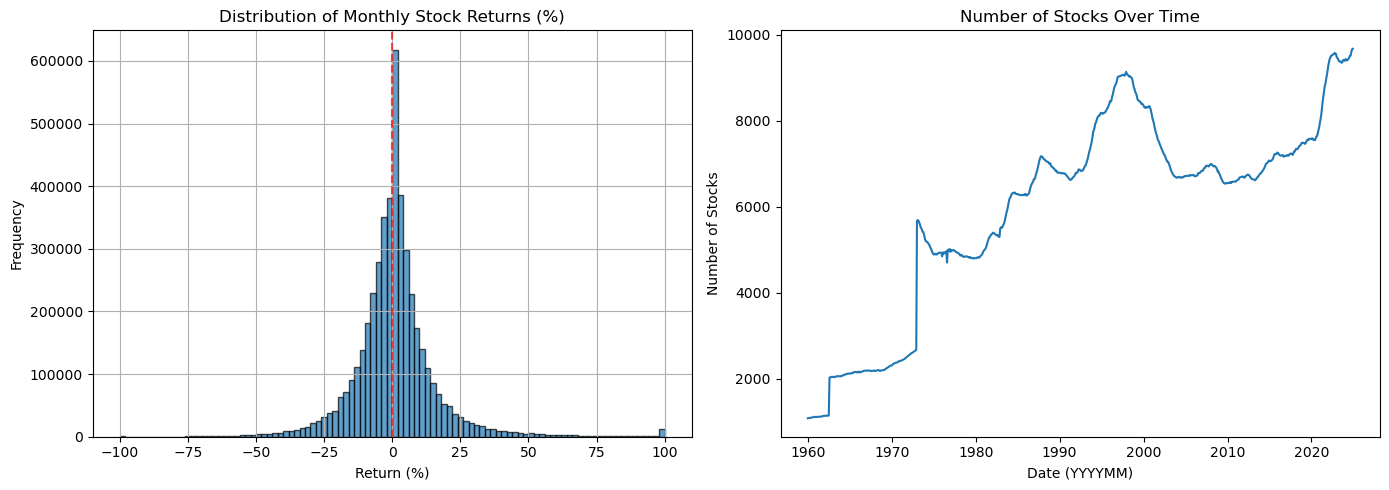

In [20]:
# Summary statistics for returns
print('=== Return Distribution ===')
print(data['ret'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Return distribution
data['ret'].dropna().clip(-100, 100).hist(bins=100, ax=axes[0], edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Monthly Stock Returns (%)')
axes[0].set_xlabel('Return (%)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(x=0, color='red', linestyle='--', alpha=0.7)

# Number of stocks over time
stocks_over_time = data.groupby('yyyymm')['permno'].nunique()
axes[1].plot(stocks_over_time.index, stocks_over_time.values)
axes[1].set_title('Number of Stocks Over Time')
axes[1].set_xlabel('Date (YYYYMM)')
axes[1].set_ylabel('Number of Stocks')

plt.tight_layout()
plt.show()

#Visual output of Return Distribution highlights data is assumed to be normally distributed for analysis

## 4. Excess Returns and Target Excess Returns

In [21]:
# Convert stock return from percentage to decimal
data['ret'] = data['ret'] / 100

# Convert annualized T-Bill to monthly decimal
rf['rf'] = rf['TB3MS'] / 100 / 12
rf       = rf[['observation_date', 'rf']].copy()
rf       = rf.rename(columns={'observation_date': 'yyyymm'})

# Merge
data = pd.merge(data, rf, on='yyyymm', how='left')
data['excess_ret'] = data['ret'] - data['rf']

# Sort and create next-month target
data = data.sort_values(['permno', 'yyyymm']).reset_index(drop=True)
data['target_excess_ret'] = data.groupby('permno')['excess_ret'].shift(-1)
data = data.drop(columns=['rf'])
data = data.dropna(subset=['target_excess_ret']).copy()

print('Shape after merge and target creation:', data.shape)
print(data[['permno', 'yyyymm', 'ret', 'excess_ret', 'target_excess_ret']].head(10))

Shape after merge and target creation: (4604060, 87)
   permno     yyyymm       ret  excess_ret  target_excess_ret
0   10000 1986-02-01 -0.257143   -0.263026           0.359918
1   10000 1986-03-01  0.365385    0.359918          -0.103642
2   10000 1986-04-01 -0.098592   -0.103642          -0.227781
3   10000 1986-05-01 -0.222656   -0.227781          -0.010200
4   10000 1986-06-01 -0.005025   -0.010200          -0.085666
5   10000 1986-07-01 -0.080808   -0.085666          -0.619993
6   10000 1986-08-01 -0.615385   -0.619993          -0.061485
7   10000 1986-09-01 -0.057143   -0.061485          -0.246741
8   10000 1986-10-01 -0.242424   -0.246741           0.055542
9   10000 1986-11-01  0.060000    0.055542          -0.381966


## 5. Preprocess Data

In [22]:
data = data.replace([np.inf, -np.inf], np.nan)

exclude_cols = ['permno', 'yyyymm', 'ret', 'excess_ret', 'target_excess_ret']
feature_cols = [col for col in data.columns if col not in exclude_cols]

# Fill missing values with monthly median
data[feature_cols] = data.groupby('yyyymm')[feature_cols].transform(
    lambda x: x.fillna(x.median())
)
data = data.dropna()

## 6. CAPM Matrix

CAPM is extracted before rank normalisation so Beta retains its original values.

In [23]:
CAPM_matrix = data[['permno', 'yyyymm', 'Beta', 'target_excess_ret']].dropna().copy()
CAPM_matrix = CAPM_matrix.dropna()

CAPM_train  = CAPM_matrix[CAPM_matrix['yyyymm'] <= '1999-12-01'].copy()
CAPM_test   = CAPM_matrix[CAPM_matrix['yyyymm'] >= '2011-01-01'].copy()

print('CAPM matrix:', CAPM_matrix.shape)

CAPM matrix: (3317629, 4)


## 7. Cross-sectional rank normalisation

In [24]:
data[feature_cols] = data.groupby('yyyymm')[feature_cols].transform(
    lambda x: 2 * x.rank(pct=True) - 1
)

## 8. Train / Validation / Test Splits

- Train:      up to Dec 1999
- Validation: Jan 2000 — Dec 2010
- Test:       Jan 2011 onwards

In [25]:
train_final      = data[data['yyyymm'] <= '1999-12-01'].copy()
validation_final = data[(data['yyyymm'] >= '2000-01-01') & (data['yyyymm'] <= '2010-12-01')].copy()
test_final       = data[data['yyyymm'] >= '2011-01-01'].copy()

print(f'{train_final.shape[0]} + {validation_final.shape[0]} + {test_final.shape[0]} = {train_final.shape[0] + validation_final.shape[0] + test_final.shape[0]}')

train_x = train_final.drop(columns=exclude_cols)
train_y = train_final[exclude_cols]

valid_x = validation_final.drop(columns=exclude_cols)
valid_y = validation_final[exclude_cols]

test_x  = test_final.drop(columns=exclude_cols)
test_y  = test_final[exclude_cols]

# Combined train+validation for Random Forest
train_validation_final = pd.concat([train_final, validation_final], axis=0)
train_validation_final = train_validation_final.sort_values(['yyyymm', 'permno']).reset_index(drop=True)

print(train_final.head())
print(validation_final.head())
print(test_final.head())

1266469 + 920924 + 1130236 = 3317629
   permno     yyyymm       prc       ret     Price      Size  STreversal  \
0   10000 1986-02-01 -0.729096 -0.257143  0.551597  0.499920    0.949286   
1   10000 1986-03-01 -0.771479  0.365385  0.466677  0.405171   -0.932552   
2   10000 1986-04-01 -0.743992 -0.098592  0.504486  0.437360    0.669657   
3   10000 1986-05-01 -0.701516 -0.222656  0.592658  0.534238    0.942219   
4   10000 1986-06-01 -0.698906 -0.005025  0.594260  0.545901    0.074045   

     MaxRet    High52  RealizedVol  ...        CF        SP  Leverage  \
0  0.141390 -0.311828    -0.331407  ...  0.000160  0.000160  0.000160   
1 -0.812590  0.476152    -0.661153  ...  0.000161  0.000161  0.000161   
2  0.689042  0.172060     0.762576  ...  0.000160  0.000160  0.000160   
3 -0.722267 -0.430487    -0.608619  ...  0.000160  0.000160  0.000160   
4  0.079594 -0.388299     0.120977  ...  0.000159  0.000159  0.000159   

   CashProd     BMdec     BPEBM       EBM  AnnouncementReturn  exce

## 9. Evaluation Metrics

### Out-of-Sample $R^2$
Following Gu, Kelly & Xiu (2020), OOS R² benchmarks against a forecast of zero:

$$R^2_{oos} = 1 - \frac{\sum_{(i,t) \in T_3} (r_{i,t+1} - \hat{r}_{i,t+1})^2}{\sum_{(i,t) \in T_3} r^2_{i,t+1}}$$

### Diebold-Mariano Test
Pairwise comparison of ML models using modified DM test with Newey-West standard errors.
Note: CAPM is reported as a standalone benchmark and is not included in DM tests.

In [26]:
def oos_r2(y_true, y_pred):
    """
    Out-of-sample R² following Gu, Kelly, Xiu (2020).
    Benchmark is a forecast of zero (not the historical mean).
    """
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum(y_true ** 2)
    return 1 - ss_res / ss_tot


def diebold_mariano_test(e1, e2, dates, max_lag=12):
    """
    Modified Diebold-Mariano test following Gu, Kelly, Xiu (2020).
    Averages squared errors cross-sectionally per month,
    then runs DM test on the resulting time series.
    Positive statistic = model 2 outperforms model 1.
    |t| > 1.96 = significant at 5% level.
    """
    tmp     = pd.DataFrame({'date': dates, 'e1_sq': e1**2, 'e2_sq': e2**2})
    monthly = tmp.groupby('date').mean()
    d       = monthly['e1_sq'] - monthly['e2_sq']

    d_mean   = d.mean()
    T        = len(d)
    d_demean = d - d_mean
    gamma_0  = np.mean(d_demean ** 2)
    nw_sum   = gamma_0

    for lag in range(1, max_lag + 1):
        w       = 1 - lag / (max_lag + 1)
        gamma_l = np.mean(d_demean.values[lag:] * d_demean.values[:-lag])
        nw_sum += 2 * w * gamma_l

    se       = np.sqrt(nw_sum / T)
    dm_stat  = d_mean / se if se > 0 else 0
    return dm_stat


# Initialise results dict — ML models only (CAPM reported separately)
results    = {}
test_dates = test_final['yyyymm'].values

print('Evaluation functions defined. ✓')

Evaluation functions defined. ✓


## 10. CAPM Benchmark

CAPM is our naive benchmark following Gu et al. (2020).
It is reported separately and not included in the DM test comparisons.

In [27]:
X_capm         = sm.add_constant(CAPM_train[['Beta']], has_constant='add')
y_capm         = CAPM_train['target_excess_ret']

capm_model     = sm.OLS(y_capm, X_capm).fit()
print(capm_model.summary())

X_test_capm    = sm.add_constant(CAPM_test[['Beta']], has_constant='add')
capm_test_pred = capm_model.predict(X_test_capm)
y_test_capm    = CAPM_test['target_excess_ret'].values

oos_r2_capm    = oos_r2(y_test_capm, capm_test_pred.values)

# CAPM reported as standalone benchmark — NOT added to results dict
print(f'CAPM OOS R2 (benchmark): {oos_r2_capm*100:.4f}%')

# Align CAPM predictions with CAPM_test (not test_final — different row counts)
capm_predictions = CAPM_test[['permno', 'yyyymm', 'target_excess_ret']].copy()
capm_predictions['capm_pred'] = capm_test_pred.values
print(f'CAPM predictions: {len(capm_predictions):,} observations')

                            OLS Regression Results                            
Dep. Variable:      target_excess_ret   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     48.15
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           3.95e-12
Time:                        05:36:41   Log-Likelihood:             2.9108e+05
No. Observations:             1266469   AIC:                        -5.822e+05
Df Residuals:                 1266467   BIC:                        -5.821e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0052      0.000     17.981      0.0

## 11. Linear Regression

Linear regression was utilised to model the relationship between dependant and independant variables. Modelling assumes a linear relationship. Outputs are a weighted sum of inputs. 

In [28]:
X_train_lr = train_x.values
X_val_lr   = valid_x.values
X_test_lr  = test_x.values

y_train_lr = train_final['target_excess_ret'].values
y_val_lr   = validation_final['target_excess_ret'].values
y_test_lr  = test_final['target_excess_ret'].values

# Fit on TRAIN only
lr_model     = LinearRegression()
lr_model.fit(X_train_lr, y_train_lr)
lr_test_pred = lr_model.predict(X_test_lr)

oos_r2_lr    = oos_r2(y_test_lr, lr_test_pred)
print(f'Linear Regression OOS R2: {oos_r2_lr*100:.4f}%')

lr_predictions = test_final[['permno', 'yyyymm', 'target_excess_ret', 'Size', 'Mom12m']].copy()
lr_predictions['lr_pred'] = lr_test_pred

results['OLS'] = {
    'r2_monthly':  oos_r2_lr,
    'predictions': lr_test_pred,
    'errors':      y_test_lr - lr_test_pred
}

print(lr_predictions.head())

Linear Regression OOS R2: -0.2213%
     permno     yyyymm  target_excess_ret      Size    Mom12m   lr_pred
315   10001 2011-01-01           0.022619  0.492465 -0.560359 -0.006007
316   10001 2011-02-01           0.072321  0.491726 -0.454076 -0.012695
317   10001 2011-03-01          -0.038839  0.478670 -0.399119 -0.012962
318   10001 2011-04-01           0.028017  0.481335 -0.428832  0.009492
319   10001 2011-05-01           0.008228  0.460236 -0.643786 -0.012696


## 12. LASSO

Lasso builds upon the use of linear regression but includes regularisation to prevent overfitting and improve model simplicity. This model includes a penalty term that shrinks irrelevant co efficents to 0. Lasso is therefore capable of performing feature selection as it minimizes less important features by shrinking their values to 0. Useful in this context due to large database, providing simpler more interpretable outputs. Please note Elastic net was not introduced in this report as it was ultimately decided that Lasso provided the most comprehensive enhanced linear evaluation. As basic linear regression was already performed. Elastic net involves an extra hyperparameter, whereas Lasso does not, indicating stronger feature selection. Considered of greater importance to this analysis. 

Tuning Lasso alpha on validation set...
Tuning took 49.0 seconds
Best lambda (alpha): 0.000543


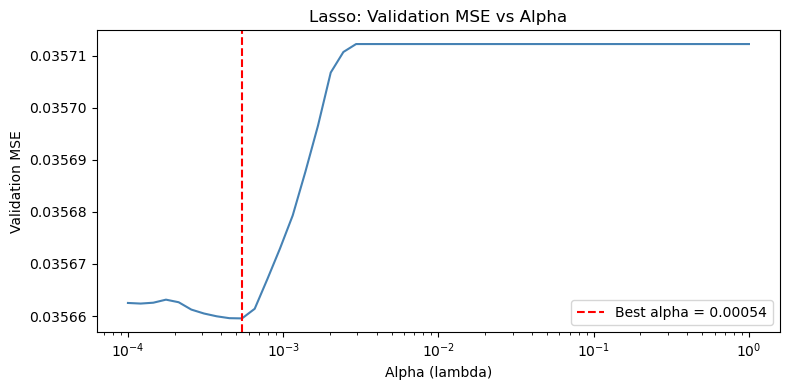

In [29]:
# Tune lambda on VALIDATION set — Gu et al. methodology
# No cross-validation — strict chronological separation

alphas   = np.logspace(-4, 0, 50)
val_mses = []

print('Tuning Lasso alpha on validation set...')
start = time.time()

for alpha in alphas:
    lasso_tmp    = Lasso(alpha=alpha, max_iter=10000, random_state=42)
    lasso_tmp.fit(X_train_lr, y_train_lr)
    val_pred_tmp = lasso_tmp.predict(X_val_lr)
    val_mses.append(np.mean((y_val_lr - val_pred_tmp)**2))

best_alpha = alphas[np.argmin(val_mses)]
print(f'Tuning took {time.time() - start:.1f} seconds')
print(f'Best lambda (alpha): {best_alpha:.6f}')

# Plot validation MSE vs alpha
plt.figure(figsize=(8, 4))
plt.plot(alphas, val_mses, color='steelblue')
plt.axvline(best_alpha, color='red', linestyle='--', label=f'Best alpha = {best_alpha:.5f}')
plt.xscale('log')
plt.xlabel('Alpha (lambda)')
plt.ylabel('Validation MSE')
plt.title('Lasso: Validation MSE vs Alpha')
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
# Fit final Lasso with best alpha
lasso_model     = Lasso(alpha=best_alpha, max_iter=10000, random_state=42)
lasso_model.fit(X_train_lr, y_train_lr)
lasso_test_pred = lasso_model.predict(X_test_lr)

oos_r2_lasso = oos_r2(y_test_lr, lasso_test_pred)
print(f'Lasso OOS R2: {oos_r2_lasso*100:.4f}%')

n_nonzero = np.sum(lasso_model.coef_ != 0)
n_total   = len(lasso_model.coef_)
print(f'Features retained by Lasso: {n_nonzero} / {n_total}')

lasso_predictions = test_final[['permno', 'yyyymm', 'target_excess_ret', 'Size', 'Mom12m']].copy()
lasso_predictions['lasso_pred'] = lasso_test_pred

results['Lasso'] = {
    'r2_monthly':  oos_r2_lasso,
    'predictions': lasso_test_pred,
    'errors':      y_test_lr - lasso_test_pred
}

print(lasso_predictions.head())

Lasso OOS R2: 0.0522%
Features retained by Lasso: 27 / 82
     permno     yyyymm  target_excess_ret      Size    Mom12m  lasso_pred
315   10001 2011-01-01           0.022619  0.492465 -0.560359   -0.001580
316   10001 2011-02-01           0.072321  0.491726 -0.454076   -0.004985
317   10001 2011-03-01          -0.038839  0.478670 -0.399119   -0.007142
318   10001 2011-04-01           0.028017  0.481335 -0.428832    0.007634
319   10001 2011-05-01           0.008228  0.460236 -0.643786   -0.005700


## 13. Principal Components Regression (PCR)

Principal Component Regression (PCR) is used as a further improvement after linear regression and Lasso to address issues caused by highly correlated predictors. It applies Principal Component Analysis (PCA) to transform the original variables into a smaller set of uncorrelated principal components, and then performs linear regression on these components.

While linear regression provides a baseline and Lasso performs feature selection, PCR focuses on removing multicollinearity by working with orthogonal components. This can lead to more stable and robust predictions, particularly when many predictors are correlated.

However, unlike Lasso, PCR does not select variables based on their relationship with the target, but rather on how much variance they explain.

In [31]:
X_train_pcr = train_x.copy().values
X_val_pcr   = valid_x.copy().values
X_test_pcr  = test_x.copy().values

y_train_pcr = train_final['target_excess_ret'].values
y_val_pcr   = validation_final['target_excess_ret'].values
y_test_pcr  = test_final['target_excess_ret'].values

scaler_pcr  = StandardScaler()
X_train_std = scaler_pcr.fit_transform(X_train_pcr)
X_val_std   = scaler_pcr.transform(X_val_pcr)
X_test_std  = scaler_pcr.transform(X_test_pcr)

n_components_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 18, 20]
best_k_pcr, best_r2_pcr = None, -np.inf

print('Tuning PCR on validation set...')
for k in n_components_list:
    if k > X_train_std.shape[1]:
        continue
    pca     = PCA(n_components=k)
    Z_train = pca.fit_transform(X_train_std)
    Z_val   = pca.transform(X_val_std)
    reg     = LinearRegression()
    reg.fit(Z_train, y_train_pcr)
    r2      = oos_r2(y_val_pcr, reg.predict(Z_val))
    print(f'  K={k:3d}: Validation R2 = {r2*100:.4f}%')
    if r2 > best_r2_pcr:
        best_r2_pcr = r2
        best_k_pcr  = k

print(f'\nBest PCR components: {best_k_pcr}')

pca_final     = PCA(n_components=best_k_pcr)
Z_train_final = pca_final.fit_transform(X_train_std)
Z_test_final  = pca_final.transform(X_test_std)

model_pcr     = LinearRegression()
model_pcr.fit(Z_train_final, y_train_pcr)
pcr_test_pred = model_pcr.predict(Z_test_final)

oos_r2_pcr    = oos_r2(y_test_pcr, pcr_test_pred)
print(f'PCR Test OOS R2: {oos_r2_pcr*100:.4f}%')
print(f'Variance explained by {best_k_pcr} components: {pca_final.explained_variance_ratio_.sum()*100:.1f}%')

pcr_predictions = test_final[['permno', 'yyyymm', 'target_excess_ret']].copy()
pcr_predictions['pcr_pred'] = pcr_test_pred

results['PCR'] = {
    'r2_monthly':  oos_r2_pcr,
    'predictions': pcr_test_pred,
    'errors':      y_test_pcr - pcr_test_pred
}

print(pcr_predictions.head())

Tuning PCR on validation set...
  K=  1: Validation R2 = 0.1338%
  K=  2: Validation R2 = 0.1709%
  K=  3: Validation R2 = 0.1462%
  K=  4: Validation R2 = 0.1401%
  K=  5: Validation R2 = 0.1375%
  K=  6: Validation R2 = 0.1441%
  K=  7: Validation R2 = 0.1306%
  K=  8: Validation R2 = 0.1520%
  K=  9: Validation R2 = 0.1640%
  K= 10: Validation R2 = 0.1638%
  K= 12: Validation R2 = 0.1650%
  K= 14: Validation R2 = 0.1468%
  K= 16: Validation R2 = 0.1402%
  K= 18: Validation R2 = 0.1485%
  K= 20: Validation R2 = 0.1613%

Best PCR components: 2
PCR Test OOS R2: 0.0927%
Variance explained by 2 components: 21.3%
     permno     yyyymm  target_excess_ret  pcr_pred
315   10001 2011-01-01           0.022619  0.008506
316   10001 2011-02-01           0.072321  0.008879
317   10001 2011-03-01          -0.038839  0.008060
318   10001 2011-04-01           0.028017  0.008421
319   10001 2011-05-01           0.008228  0.008194


## 14. Random Forests

Random Forest is an ensemble learning method that builds multiple decision trees and combines their predictions to improve accuracy and reduce overfitting. Each tree is trained on a random subset of the data (bootstrap sampling) and uses a random subset of features when making splits.

By averaging the predictions of many trees, Random Forest reduces variance compared to a single decision tree, leading to more robust and stable performance.

In the context of this assignment, Random Forest provides a non-linear alternative to linear models such as linear regression, Lasso, and PCR. While those models assume linear relationships, Random Forest can capture complex interactions between variables.

In [32]:
# ============================================================
# RANDOM FOREST
# Train on TRAIN only
# Tune hyperparameters on VALIDATION only
# Evaluate on TEST only
# No cross-validation
# ============================================================

X_train_rf = train_final.drop(columns=exclude_cols).copy()
y_train_rf = train_final['target_excess_ret'].copy()

X_val_rf = validation_final.drop(columns=exclude_cols).copy()
y_val_rf = validation_final['target_excess_ret'].copy()

X_test_rf = test_final.drop(columns=exclude_cols).copy()
y_test_rf = test_final['target_excess_ret'].copy()

# Small grid to keep runtime reasonable
rf_param_grid = [
    {'n_estimators': 500, 'max_depth': 2, 'min_samples_leaf': 50,  'max_features': 0.1},
    {'n_estimators': 500, 'max_depth': 3, 'min_samples_leaf': 50,  'max_features': 0.1},
    {'n_estimators': 500, 'max_depth': 5, 'min_samples_leaf': 50,  'max_features': 0.1},
    {'n_estimators': 500, 'max_depth': 3, 'min_samples_leaf': 100, 'max_features': 0.2},
    {'n_estimators': 500, 'max_depth': 5, 'min_samples_leaf': 100, 'max_features': 0.2},
    {'n_estimators': 500, 'max_depth': 8, 'min_samples_leaf': 100, 'max_features': 'sqrt'},
    {'n_estimators': 500, 'max_depth': 3, 'min_samples_leaf': 300, 'max_features': 0.1},
    {'n_estimators': 500, 'max_depth': 5, 'min_samples_leaf': 300, 'max_features': 0.2},
]

rf_tuning_results = []

print('\nTuning Random Forest on validation set...')

for params in rf_param_grid:
    rf_model = RandomForestRegressor(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        min_samples_leaf=params['min_samples_leaf'],
        max_features=params['max_features'],
        random_state=42,
        n_jobs=-1
    )

    # Fit on TRAIN only
    rf_model.fit(X_train_rf, y_train_rf)

    # Predict on VALIDATION
    val_pred = rf_model.predict(X_val_rf)

    # Validation metrics
    val_mse = np.mean((y_val_rf.values - val_pred) ** 2)
    val_r2 = oos_r2(y_val_rf.values, val_pred)

    rf_tuning_results.append({
        'params': params,
        'val_mse': val_mse,
        'val_r2': val_r2
    })

    print(f'Params: {params} | Validation MSE: {val_mse:.6f} | Validation OOS R2: {val_r2:.6f}')

# Choose best params by highest validation OOS R2
best_rf_result = max(rf_tuning_results, key=lambda x: x['val_r2'])
best_rf_params = best_rf_result['params']

print('\nBest RF params based on validation OOS R2:')
print(best_rf_params)
print(f'Best validation OOS R2: {best_rf_result["val_r2"]:.6f}')

# ------------------------------------------------------------
# Final RF fit — strict paper style: TRAIN only
# ------------------------------------------------------------
best_rf = RandomForestRegressor(
    n_estimators=best_rf_params['n_estimators'],
    max_depth=best_rf_params['max_depth'],
    min_samples_leaf=best_rf_params['min_samples_leaf'],
    max_features=best_rf_params['max_features'],
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train_rf, y_train_rf)

# Test prediction
rf_test_pred = best_rf.predict(X_test_rf)
oos_r2_rf = oos_r2(y_test_rf.values, rf_test_pred)

print(f'RF Test OOS R2: {oos_r2_rf*100:.4f}%')

rf_predictions = test_final[['permno', 'yyyymm', 'target_excess_ret', 'Size', 'Mom12m']].copy()
rf_predictions['rf_pred'] = rf_test_pred

results['RF'] = {
    'r2_monthly': oos_r2_rf,
    'predictions': rf_test_pred,
    'errors': y_test_rf.values - rf_test_pred
}


Tuning Random Forest on validation set...
Params: {'n_estimators': 500, 'max_depth': 2, 'min_samples_leaf': 50, 'max_features': 0.1} | Validation MSE: 0.035800 | Validation OOS R2: -0.001321
Params: {'n_estimators': 500, 'max_depth': 3, 'min_samples_leaf': 50, 'max_features': 0.1} | Validation MSE: 0.035885 | Validation OOS R2: -0.003701
Params: {'n_estimators': 500, 'max_depth': 5, 'min_samples_leaf': 50, 'max_features': 0.1} | Validation MSE: 0.036078 | Validation OOS R2: -0.009109
Params: {'n_estimators': 500, 'max_depth': 3, 'min_samples_leaf': 100, 'max_features': 0.2} | Validation MSE: 0.035962 | Validation OOS R2: -0.005861
Params: {'n_estimators': 500, 'max_depth': 5, 'min_samples_leaf': 100, 'max_features': 0.2} | Validation MSE: 0.036288 | Validation OOS R2: -0.014975
Params: {'n_estimators': 500, 'max_depth': 8, 'min_samples_leaf': 100, 'max_features': 'sqrt'} | Validation MSE: 0.036344 | Validation OOS R2: -0.016535
Params: {'n_estimators': 500, 'max_depth': 3, 'min_sample

## 15. Neural Networks (NN1, NN3, NN5)

This project implements various neural network depths to model non-linear relationships in data. The networks consists of multiple layers of neurons that learn patterns through weighted sums and activation functions.

The ReLU activation function is used in the hidden layers to introduce non-linearity and improve computational efficiency. Model parameters are optimised using the Adam optimiser, which combines momentum (using past gradients) and adaptive learning rates (scaling updates based on gradient variance). This allows each parameter to be updated efficiently, leading to faster and more stable convergence during training.

The network is trained using backpropagation to minimise a loss function and improve prediction accuracy.

In [33]:
# NEURAL NETWORK

# Prepare train / validation / test data
X_train_nn = train_x.copy()
X_val_nn   = valid_x.copy()
X_test_nn  = test_x.copy()

y_train_nn = train_final['target_excess_ret'].copy().values
y_val_nn   = validation_final['target_excess_ret'].copy().values
y_test_nn  = test_final['target_excess_ret'].copy().values

# Keep feature names for reference
nn_feature_names = X_train_nn.columns.tolist()

# Convert DataFrames to numpy
X_train_nn = X_train_nn.values
X_val_nn   = X_val_nn.values
X_test_nn  = X_test_nn.values

# Standardize features
scaler_nn = StandardScaler() # we scale the dataset again using the (x-μ)/σ (standard scaler)
X_train_nn = scaler_nn.fit_transform(X_train_nn)
X_val_nn   = scaler_nn.transform(X_val_nn)
X_test_nn  = scaler_nn.transform(X_test_nn)

# Verify data
print('\nData validation before NN training:')
print(f'  X_train — NaN: {np.isnan(X_train_nn).sum()}, Inf: {np.isinf(X_train_nn).sum()}')
print(f'  X_val   — NaN: {np.isnan(X_val_nn).sum()}, Inf: {np.isinf(X_val_nn).sum()}')
print(f'  X_test  — NaN: {np.isnan(X_test_nn).sum()}, Inf: {np.isinf(X_test_nn).sum()}')
print(f'  y_train — NaN: {np.isnan(y_train_nn).sum()}, Inf: {np.isinf(y_train_nn).sum()}')
print(f'  y_train — min: {y_train_nn.min():.4f}, max: {y_train_nn.max():.4f}, mean: {y_train_nn.mean():.6f}')
print(f'  y_train — extreme values (|y| > 1): {(np.abs(y_train_nn) > 1).sum()}')

# safety checks to make sure the data has no missing values
assert np.isnan(X_train_nn).sum() == 0, 'ERROR: NaN in X_train_nn!'
assert np.isnan(X_val_nn).sum() == 0, 'ERROR: NaN in X_val_nn!'
assert np.isnan(X_test_nn).sum() == 0, 'ERROR: NaN in X_test_nn!'
assert np.isnan(y_train_nn).sum() == 0, 'ERROR: NaN in y_train_nn!'
assert np.isnan(y_val_nn).sum() == 0, 'ERROR: NaN in y_val_nn!'
assert np.isnan(y_test_nn).sum() == 0, 'ERROR: NaN in y_test_nn!'

print('  All NN checks passed. ✓')

# This class defines a feedforward neural network that takes stock features as input,
# passes them through multiple hidden layers (Linear + BatchNorm + ReLU + Dropout),
# and outputs a single value: the predicted next-month excess return.
class ReturnPredictor(nn.Module):
    def __init__(self, input_dim, hidden_layers, dropout=0.1):
        super(ReturnPredictor, self).__init__()
        layers = []
        prev_dim = input_dim
        
        for h_dim in hidden_layers:
            layers.append(nn.Linear(prev_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = h_dim
        
        layers.append(nn.Linear(prev_dim, 1))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x).squeeze(-1)

# Train function
def train_neural_network(X_train, y_train, X_val, y_val, hidden_layers, 
                         lr=0.001, epochs=100, batch_size=1024, patience=10,
                         n_ensemble=3, weight_decay=1e-4, dropout=0.1):
    """
    Train NN with:
    - early stopping
    - ensemble averaging
    - Huber loss
    - gradient clipping
    - target clipping
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    input_dim = X_train.shape[1]
    
    # Winsorize targets
    y_lower = np.percentile(y_train, 1)
    y_upper = np.percentile(y_train, 99)
    y_train_clipped = np.clip(y_train, y_lower, y_upper)
    y_val_clipped   = np.clip(y_val, y_lower, y_upper)
    
    print(f'    Target clipped to [{y_lower:.4f}, {y_upper:.4f}]')
    
    # Convert to tensors
    X_tr = torch.FloatTensor(X_train).to(device)
    y_tr = torch.FloatTensor(y_train_clipped).to(device)
    X_v  = torch.FloatTensor(X_val).to(device)
    y_v  = torch.FloatTensor(y_val_clipped).to(device)
    
    train_dataset = TensorDataset(X_tr, y_tr)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    criterion = nn.HuberLoss(delta=1.0)
    
    all_models = []
    
    for seed in range(n_ensemble):
        torch.manual_seed(seed)
        np.random.seed(seed)
        random.seed(seed)
        
        if torch.cuda.is_available():
            torch.cuda.manual_seed(seed)
            torch.cuda.manual_seed_all(seed)
        
        model = ReturnPredictor(input_dim, hidden_layers, dropout=dropout).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        
        best_val_loss = np.inf
        patience_counter = 0
        best_state = None
        
        for epoch in range(epochs):
            model.train()
            train_loss_sum = 0.0
            
            for X_batch, y_batch in train_loader:
                optimizer.zero_grad()
                pred = model(X_batch)
                loss = criterion(pred, y_batch)
                loss.backward()
                
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                
                train_loss_sum += loss.item() * X_batch.size(0)
            
            avg_train_loss = train_loss_sum / len(train_loader.dataset)
            
            model.eval()
            with torch.no_grad():
                val_pred = model(X_v)
                val_loss = criterion(val_pred, y_v).item()
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                patience_counter = 0
            else:
                patience_counter += 1
            
            if epoch % 10 == 0 or epoch == epochs - 1:
                print(f'      Epoch {epoch+1:3d} | train_loss={avg_train_loss:.6f} | val_loss={val_loss:.6f}')
            
            if patience_counter >= patience:
                print(f'      Early stopping at epoch {epoch+1}')
                break
        
        model.load_state_dict(best_state)
        model = model.to(device)
        all_models.append(model)
        print(f'    Ensemble {seed+1}/{n_ensemble} done (best val_loss={best_val_loss:.6f})')
    
    return all_models

# Prediction function
def predict_ensemble(models, X, device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    X_t = torch.FloatTensor(X).to(device)
    preds = []
    
    for model in models:
        model.eval()
        with torch.no_grad():
            preds.append(model(X_t).cpu().numpy())
    
    return np.mean(preds, axis=0)

print('\nNeural network classes defined. ✓')
print(f'Device: {torch.device("cuda" if torch.cuda.is_available() else "cpu")}')

# Define architectures
nn_configs = {
    'NN1': {'layers': [128, 64],              'lr': 0.0001, 'dropout': 0.3, 'weight_decay': 1e-3},
    'NN3': {'layers': [64, 32, 16],       'lr': 0.001,  'dropout': 0.1, 'weight_decay': 1e-4},
    'NN5': {'layers': [32, 16, 8, 4, 2], 'lr': 0.001,  'dropout': 0.1, 'weight_decay': 1e-4},
}

# Train all NN architectures
nn_models = {}
nn_results = {}

for name, config in nn_configs.items():
    print(f'\nTraining {name} with layers {config["layers"]} '
          f'(lr={config["lr"]}, dropout={config["dropout"]}, wd={config["weight_decay"]})...')
    
    models = train_neural_network(
        X_train_nn, y_train_nn,
        X_val_nn, y_val_nn,
        hidden_layers=config['layers'],
        lr=config['lr'],
        dropout=config['dropout'],
        weight_decay=config['weight_decay'],
        epochs=100,
        batch_size=1024,
        patience=10,
        n_ensemble=3
    )
    
    nn_models[name] = models
    
    # Validation prediction
    val_pred = predict_ensemble(models, X_val_nn)
    val_r2 = 1 - np.sum((y_val_nn - val_pred)**2) / np.sum((y_val_nn)**2)
    
    # Test prediction
    test_pred = predict_ensemble(models, X_test_nn)
    test_r2 = 1 - np.sum((y_test_nn - test_pred)**2) / np.sum((y_test_nn)**2)
    
    print(f'    Validation OOS R2: {val_r2:.6f}')
    print(f'    Test OOS R2:       {test_r2:.6f}')
    print(f'    Predictions — min: {test_pred.min():.4f}, max: {test_pred.max():.4f}, mean: {test_pred.mean():.6f}')
    
    if np.abs(test_pred).max() > 1:
        print('    WARNING: Some predictions exceed ±1')
    
    nn_results[name] = {
        'val_r2': val_r2,
        'test_r2': test_r2,
        'test_pred': test_pred
    }

# Pick best NN based on validation R2
best_nn_name = max(nn_results, key=lambda k: nn_results[k]['val_r2'])
best_nn_pred = nn_results[best_nn_name]['test_pred']

print(f'\nBest NN based on validation R2: {best_nn_name}')
print(f'Best NN test OOS R2: {nn_results[best_nn_name]["test_r2"]:.6f}')

# Store best NN predictions
nn_predictions = test_final[['permno','yyyymm','target_excess_ret','Size','Mom12m']].copy()
nn_predictions['nn_pred'] = best_nn_pred

print('\nNN predictions sample:')
print(nn_predictions.head())


# ============================================================
# Store best NN in main results dict for analysis section
# ============================================================
results[best_nn_name] = {
    'r2_monthly':  nn_results[best_nn_name]['test_r2'],
    'predictions': best_nn_pred,
    'errors':      y_test_nn - best_nn_pred
}
print(f'\n{best_nn_name} added to results dict for analysis. ✓')



Data validation before NN training:
  X_train — NaN: 0, Inf: 0
  X_val   — NaN: 0, Inf: 0
  X_test  — NaN: 0, Inf: 0
  y_train — NaN: 0, Inf: 0
  y_train — min: -1.0073, max: 23.9968, mean: 0.006779
  y_train — extreme values (|y| > 1): 3646
  All NN checks passed. ✓

Neural network classes defined. ✓
Device: cuda

Training NN1 with layers [128, 64] (lr=0.0001, dropout=0.3, wd=0.001)...
    Target clipped to [-0.4121, 0.5992]
      Epoch   1 | train_loss=0.045898 | val_loss=0.012494
      Epoch  11 | train_loss=0.011709 | val_loss=0.011773
      Epoch  21 | train_loss=0.011723 | val_loss=0.011774
      Early stopping at epoch 21
    Ensemble 1/3 done (best val_loss=0.011773)
      Epoch   1 | train_loss=0.037328 | val_loss=0.012114
      Epoch  11 | train_loss=0.011707 | val_loss=0.011777
      Early stopping at epoch 17
    Ensemble 2/3 done (best val_loss=0.011771)
      Epoch   1 | train_loss=0.034601 | val_loss=0.012262
      Epoch  11 | train_loss=0.011711 | val_loss=0.011777
   

## 16. Analysis & Interpretation

### 16a. OOS R² Table

Out-of-Sample R² Comparison (Monthly)
                  Monthly OOS R² (%)
Model                               
PCR                         0.092716
NN3                         0.071548
CAPM (benchmark)            0.065019
Lasso                       0.052199
RF                         -0.140700
OLS                        -0.221337


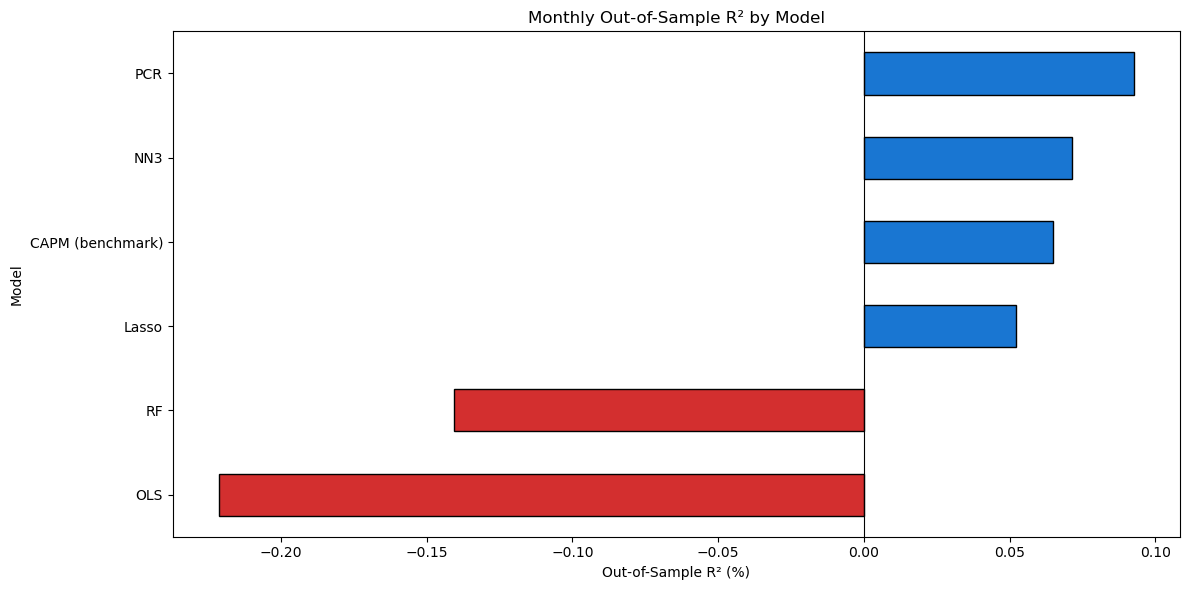

In [34]:
# Build table — include CAPM as a reference row
r2_table = pd.DataFrame([
    {'Model': name, 'Monthly OOS R² (%)': vals['r2_monthly'] * 100}
    for name, vals in results.items()
])

# Add CAPM as benchmark row
capm_row = pd.DataFrame([{'Model': 'CAPM (benchmark)', 'Monthly OOS R² (%)': oos_r2_capm * 100}])
r2_table = pd.concat([capm_row, r2_table], ignore_index=True).set_index('Model')
r2_table = r2_table.sort_values('Monthly OOS R² (%)', ascending=False)

print('=' * 50)
print('Out-of-Sample R² Comparison (Monthly)')
print('=' * 50)
print(r2_table.to_string())
print('=' * 50)

fig, ax = plt.subplots(figsize=(12, 6))
colors  = ['#d32f2f' if v < 0 else '#1976d2' for v in r2_table['Monthly OOS R² (%)']]
r2_table['Monthly OOS R² (%)'].plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Out-of-Sample R² (%)')
ax.set_title('Monthly Out-of-Sample R² by Model')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 16b. Diebold-Mariano Tests

Pairwise DM tests across ML models only, highlighting predictive accuracy across models. CAPM excluded as it uses a different stock universe.

In this assignment, the Diebold–Mariano test is useful for determining whether improvements from models such as Lasso, PCR, or Random Forest over linear regression are statistically meaningful, rather than due to random variation.

In [35]:
model_names = list(results.keys())   # CAPM not in here
n_models    = len(model_names)
dm_matrix   = pd.DataFrame(np.zeros((n_models, n_models)),
                            index=model_names, columns=model_names)

for i, m1 in enumerate(model_names):
    for j, m2 in enumerate(model_names):
        if i >= j:
            continue
        e1 = results[m1]['errors']
        e2 = results[m2]['errors']
        dm = diebold_mariano_test(e1, e2, test_dates)
        dm_matrix.loc[m1, m2] =  dm
        dm_matrix.loc[m2, m1] = -dm

print('Diebold-Mariano Test Statistics')
print('(Positive = column model outperforms row model)')
print('(|t| > 1.96 = significant at 5% level)')
print()
print(dm_matrix.round(2).to_string())

Diebold-Mariano Test Statistics
(Positive = column model outperforms row model)
(|t| > 1.96 = significant at 5% level)

        OLS  Lasso   PCR    RF   NN3
OLS    0.00   7.51  7.17  0.50  0.82
Lasso -7.51   0.00  1.09 -0.65 -0.10
PCR   -7.17  -1.09  0.00 -0.79 -0.23
RF    -0.50   0.65  0.79  0.00  0.21
NN3   -0.82   0.10  0.23 -0.21  0.00


### 16c. Variable Importance Analysis

Computing variable importance...
  OLS...
  Lasso...
  RF (built-in)...
  NN3...
Done! ✓


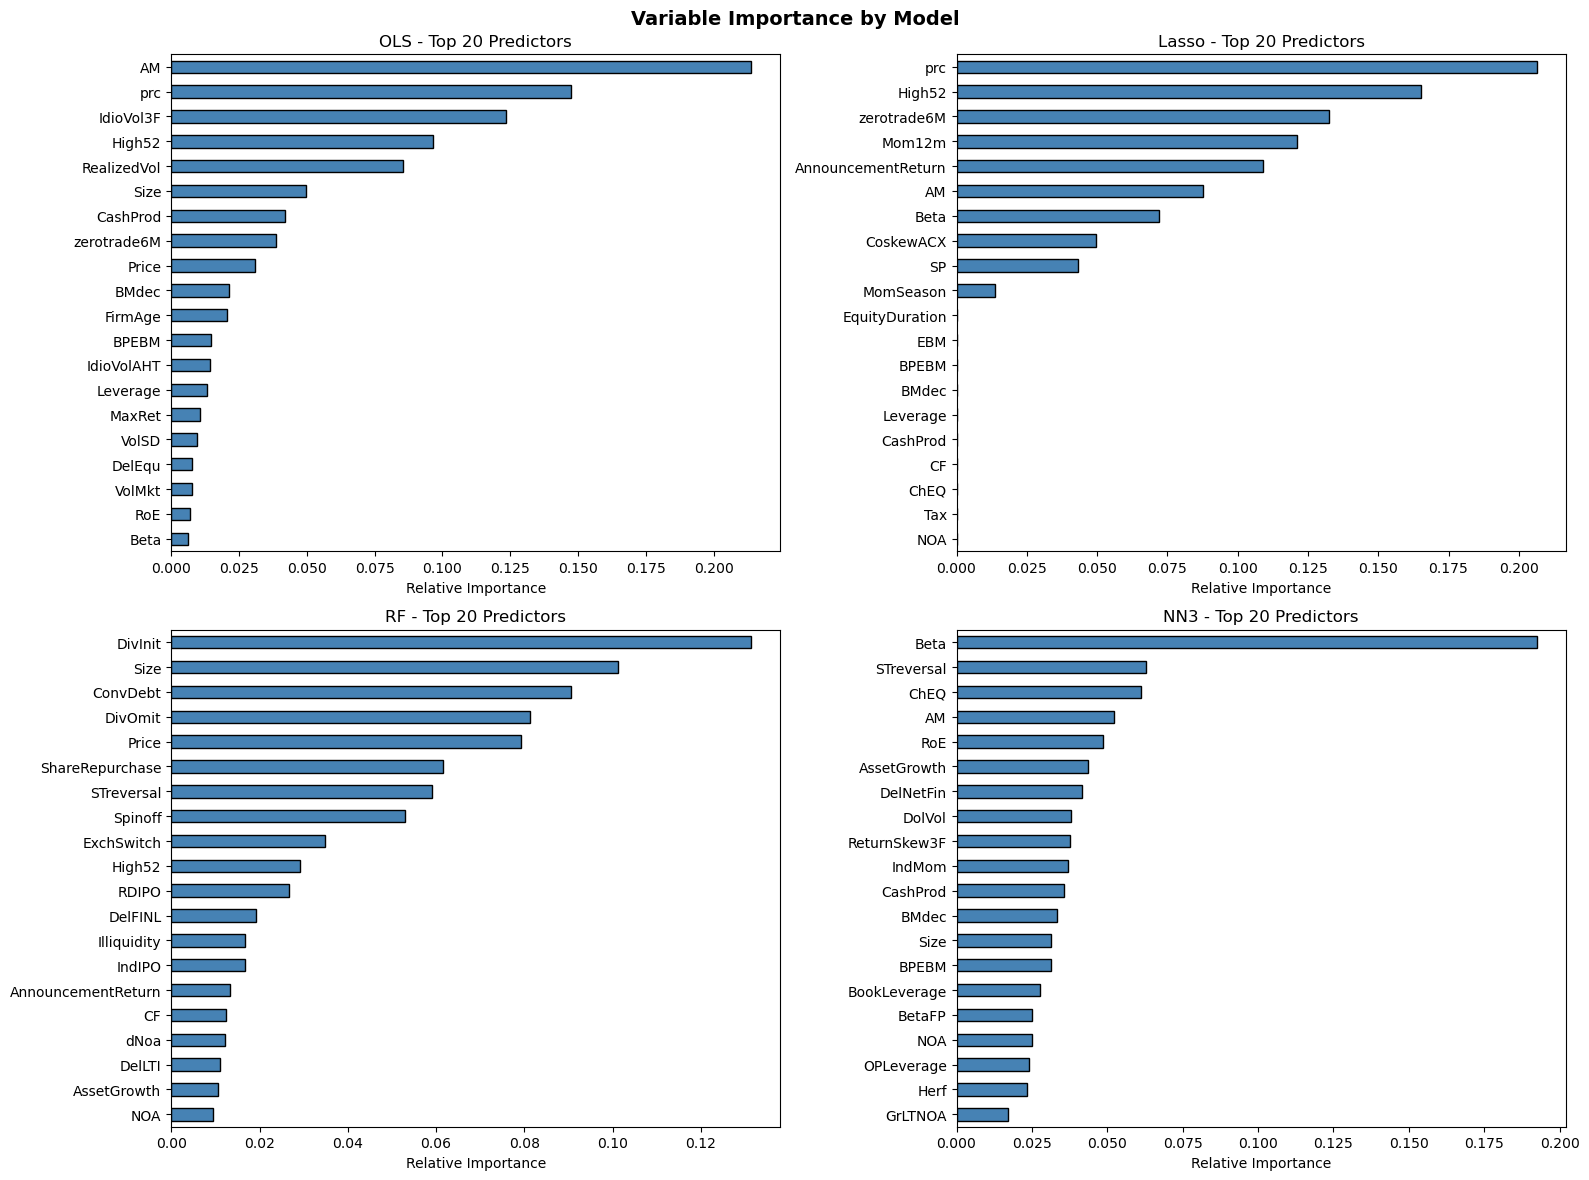

In [36]:
def compute_variable_importance(model_obj, X_test_data, y_test_data,
                                predictor_names, model_type='sklearn', nn_models_list=None):
    base_pred = predict_ensemble(nn_models_list, X_test_data) if model_type == 'nn' else model_obj.predict(X_test_data)
    base_r2   = oos_r2(y_test_data, base_pred)
    importance = {}
    for j, col in enumerate(predictor_names):
        X_zeroed       = X_test_data.copy()
        X_zeroed[:, j] = 0
        pred_zeroed    = predict_ensemble(nn_models_list, X_zeroed) if model_type == 'nn' else model_obj.predict(X_zeroed)
        importance[col] = max(base_r2 - oos_r2(y_test_data, pred_zeroed), 0)
    total = sum(importance.values())
    if total > 0:
        importance = {k: v / total for k, v in importance.items()}
    return importance


print('Computing variable importance...')
vi_results = {}

print('  OLS...')
vi_results['OLS']   = compute_variable_importance(lr_model,    X_test_lr,  y_test_lr,  feature_cols)

print('  Lasso...')
vi_results['Lasso'] = compute_variable_importance(lasso_model, X_test_lr,  y_test_lr,  feature_cols)

print('  RF (built-in)...')
rf_imp_norm         = best_rf.feature_importances_ / best_rf.feature_importances_.sum()
vi_results['RF']    = dict(zip(X_train_rf.columns, rf_imp_norm))

print(f'  {best_nn_name}...')
vi_results[best_nn_name] = compute_variable_importance(
    None, X_test_nn, y_test_nn, nn_feature_names,
    model_type='nn', nn_models_list=nn_models[best_nn_name])

print('Done! ✓')

n_vi_models = len(vi_results)
n_cols = 2
n_rows = (n_vi_models + 1) // 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 6 * n_rows))
axes = axes.flatten() if n_vi_models > 2 else [axes] if n_vi_models == 1 else axes.flatten()
for idx, (model_name, vi) in enumerate(vi_results.items()):
    pd.Series(vi).sort_values(ascending=True).tail(20).plot(
        kind='barh', ax=axes[idx], color='steelblue', edgecolor='black')
    axes[idx].set_title(f'{model_name} - Top 20 Predictors')
    axes[idx].set_xlabel('Relative Importance')

# Hide unused subplots
for idx in range(n_vi_models, len(axes)):
    axes[idx].set_visible(False)
plt.suptitle('Variable Importance by Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 16d. Portfolios

In [37]:
def form_decile_portfolios(df_test, predictions):
    df_port              = df_test[['permno', 'yyyymm', 'target_excess_ret', 'Size']].copy()
    df_port['prediction'] = predictions
    df_port['weight']    = df_port.groupby('yyyymm')['Size'].transform(
        lambda x: np.exp(x) / np.exp(x).sum())
    df_port['decile']    = df_port.groupby('yyyymm')['prediction'].transform(
        lambda x: pd.qcut(x, 10, labels=False, duplicates='drop') + 1)

    def vw_return(group):
        w = group['weight'] / group['weight'].sum()
        return (w * group['target_excess_ret']).sum()

    decile_returns = df_port.groupby(['yyyymm', 'decile']).apply(vw_return).unstack()
    summary        = pd.DataFrame({
        'Pred': df_port.groupby('decile')['prediction'].mean(),
        'Avg':  decile_returns.mean(),
        'SD':   decile_returns.std(),
        'SR':   decile_returns.mean() / decile_returns.std() * np.sqrt(12)
    })
    if 10 in decile_returns.columns and 1 in decile_returns.columns:
        ls     = decile_returns[10] - decile_returns[1]
        ls_row = pd.DataFrame([{'Pred': summary.loc[10,'Pred'] - summary.loc[1,'Pred'],
                                 'Avg': ls.mean(), 'SD': ls.std(),
                                 'SR':  ls.mean() / ls.std() * np.sqrt(12)}], index=['H-L'])
        summary = pd.concat([summary, ls_row])
    return summary, decile_returns


portfolio_results = {}
portfolio_returns = {}
key_models        = ['OLS', 'Lasso', 'PCR', 'RF', best_nn_name]

for name in key_models:
    if name not in results: continue
    preds = results[name]['predictions']
    if len(preds) != len(test_final): continue
    summary, dec_rets            = form_decile_portfolios(test_final, preds)
    portfolio_results[name]      = summary
    portfolio_returns[name]      = dec_rets
    print(f'\n{"="*60}\n{name} - Decile Portfolio Performance\n{"="*60}')
    print(summary.round(4).to_string())

C:\Users\kosta\AppData\Local\Temp\ipykernel_36260\39603166.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  decile_returns = df_port.groupby(['yyyymm', 'decile']).apply(vw_return).unstack()



OLS - Decile Portfolio Performance
       Pred     Avg      SD      SR
1   -0.0173 -0.0042  0.0586 -0.2483
2   -0.0063  0.0006  0.0498  0.0411
3   -0.0012  0.0026  0.0454  0.1975
4    0.0026  0.0040  0.0442  0.3119
5    0.0057  0.0039  0.0436  0.3085
6    0.0087  0.0047  0.0457  0.3533
7    0.0118  0.0053  0.0467  0.3958
8    0.0152  0.0068  0.0480  0.4895
9    0.0196  0.0073  0.0503  0.5008
10   0.0289  0.0115  0.0611  0.6541
H-L  0.0462  0.0157  0.0311  1.7550


C:\Users\kosta\AppData\Local\Temp\ipykernel_36260\39603166.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  decile_returns = df_port.groupby(['yyyymm', 'decile']).apply(vw_return).unstack()



Lasso - Decile Portfolio Performance
       Pred     Avg      SD      SR
1   -0.0073 -0.0049  0.0556 -0.3035
2   -0.0005 -0.0002  0.0473 -0.0181
3    0.0025  0.0030  0.0431  0.2444
4    0.0046  0.0039  0.0412  0.3313
5    0.0062  0.0044  0.0424  0.3579
6    0.0077  0.0049  0.0440  0.3880
7    0.0093  0.0050  0.0468  0.3722
8    0.0111  0.0065  0.0521  0.4298
9    0.0139  0.0073  0.0627  0.4020
10   0.0203  0.0129  0.0654  0.6841
H-L  0.0275  0.0178  0.0351  1.7554


C:\Users\kosta\AppData\Local\Temp\ipykernel_36260\39603166.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  decile_returns = df_port.groupby(['yyyymm', 'decile']).apply(vw_return).unstack()



PCR - Decile Portfolio Performance
       Pred     Avg      SD      SR
1    0.0011  0.0003  0.0826  0.0145
2    0.0036 -0.0034  0.0730 -0.1635
3    0.0049  0.0002  0.0674  0.0124
4    0.0059  0.0006  0.0599  0.0324
5    0.0067  0.0048  0.0529  0.3168
6    0.0075  0.0046  0.0451  0.3525
7    0.0081  0.0064  0.0408  0.5459
8    0.0088  0.0070  0.0371  0.6534
9    0.0097  0.0079  0.0337  0.8160
10   0.0114  0.0107  0.0335  1.1086
H-L  0.0103  0.0104  0.0613  0.5869


C:\Users\kosta\AppData\Local\Temp\ipykernel_36260\39603166.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  decile_returns = df_port.groupby(['yyyymm', 'decile']).apply(vw_return).unstack()



RF - Decile Portfolio Performance
       Pred     Avg      SD      SR
1    0.0063  0.0052  0.0402  0.4489
2    0.0066  0.0063  0.0394  0.5535
3    0.0072  0.0057  0.0383  0.5137
4    0.0082  0.0040  0.0382  0.3627
5    0.0086  0.0035  0.0426  0.2842
6    0.0092  0.0045  0.0468  0.3352
7    0.0103  0.0048  0.0526  0.3195
8    0.0127  0.0046  0.0570  0.2826
9    0.0157  0.0040  0.0566  0.2422
10   0.0207  0.0036  0.0859  0.1470
H-L  0.0143 -0.0016  0.0657 -0.0826

NN3 - Decile Portfolio Performance
       Pred     Avg      SD      SR
1   -0.0284 -0.0098  0.0845 -0.4013
2   -0.0102 -0.0005  0.0637 -0.0248
3   -0.0022  0.0047  0.0428  0.3842
4    0.0012  0.0037  0.0353  0.3616
5    0.0032  0.0042  0.0355  0.4067
6    0.0046  0.0049  0.0369  0.4622
7    0.0059  0.0062  0.0401  0.5317
8    0.0075  0.0083  0.0454  0.6304
9    0.0101  0.0103  0.0543  0.6558
10   0.0187  0.0163  0.0619  0.9105
H-L  0.0471  0.0260  0.0434  2.0802


C:\Users\kosta\AppData\Local\Temp\ipykernel_36260\39603166.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  decile_returns = df_port.groupby(['yyyymm', 'decile']).apply(vw_return).unstack()


Long-Short (H-L) Portfolio Comparison
       H-L Sharpe Ratio  H-L Monthly Return (%)
NN3              2.0802                  0.0260
Lasso            1.7554                  0.0178
OLS              1.7550                  0.0157
PCR              0.5869                  0.0104
RF              -0.0826                 -0.0016


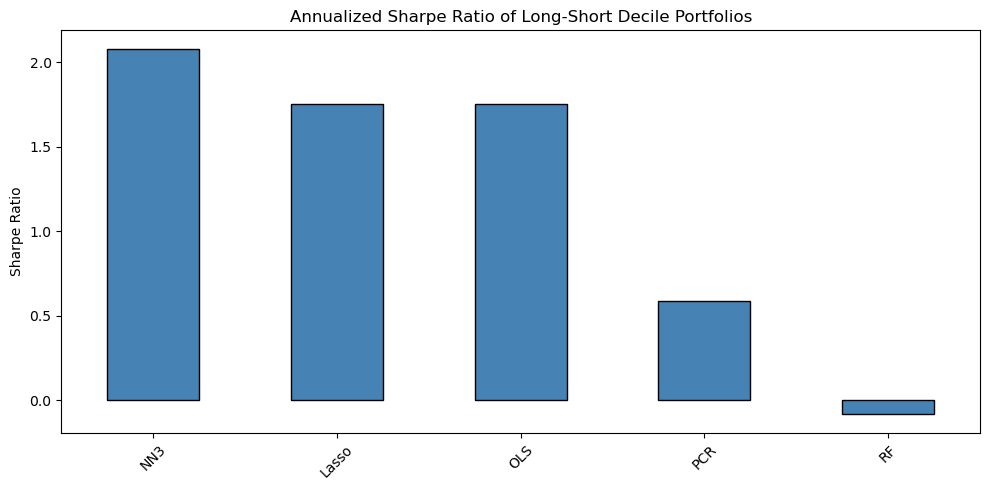

In [38]:
# Sharpe Ratio Comparison
sharpe_comparison = pd.DataFrame({
    model: {'H-L Sharpe Ratio':       port.loc['H-L', 'SR']  if 'H-L' in port.index else np.nan,
            'H-L Monthly Return (%)': port.loc['H-L', 'Avg'] if 'H-L' in port.index else np.nan}
    for model, port in portfolio_results.items()
}).T.sort_values('H-L Sharpe Ratio', ascending=False)

print('Long-Short (H-L) Portfolio Comparison\n' + '='*50)
print(sharpe_comparison.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
sharpe_comparison['H-L Sharpe Ratio'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Annualized Sharpe Ratio of Long-Short Decile Portfolios')
ax.set_ylabel('Sharpe Ratio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

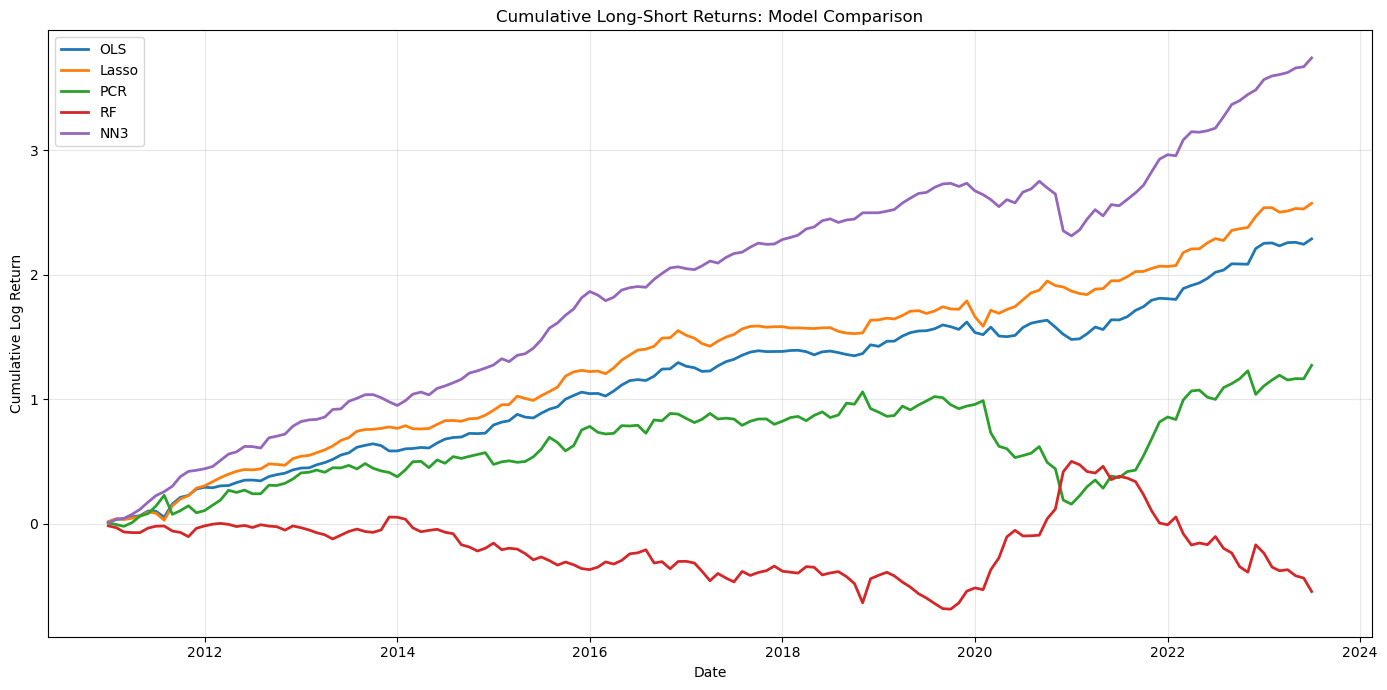

In [39]:
# Cumulative Long-Short Returns
fig, ax = plt.subplots(figsize=(14, 7))
for name in key_models:
    if name not in portfolio_returns: continue
    dec_rets = portfolio_returns[name]
    if 10 in dec_rets.columns and 1 in dec_rets.columns:
        # Returns already in decimal — do NOT divide by 100
        cum_ls = np.log(1 + (dec_rets[10] - dec_rets[1])).cumsum()
        ax.plot(cum_ls.index, cum_ls.values, label=name, linewidth=2)
ax.set_title('Cumulative Long-Short Returns: Model Comparison')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Log Return')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 16e. Annual Return Forecasts

We aggregate monthly predictions into annual forecasts and recompute $R^2$, as required by the assignment.

Annual Out-of-Sample R²
                  Annual OOS R² (%)
Model                              
NN3                          1.3335
Lasso                        1.2481
PCR                          1.2379
CAPM (benchmark)             1.1944
OLS                         -0.6817
RF                          -2.2794


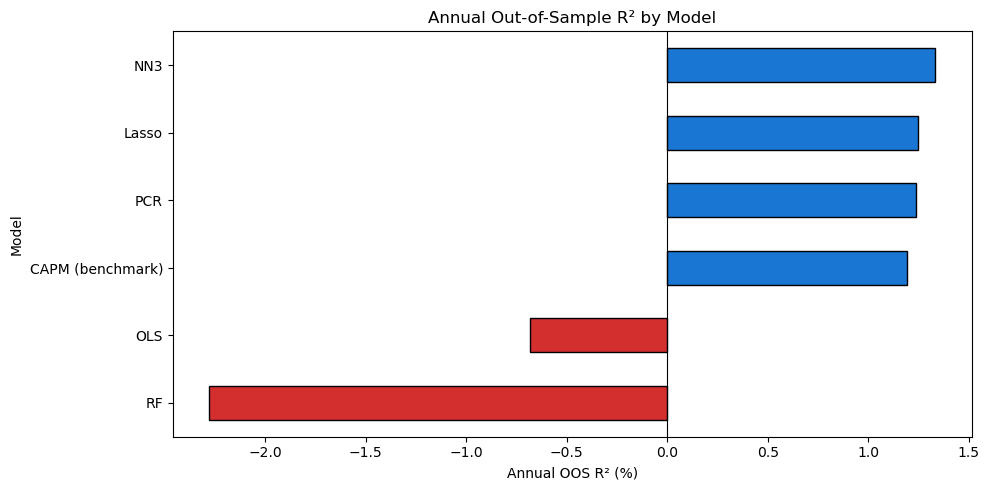

In [40]:
# Annual OOS R² — aggregate monthly predictions to annual
df_test_annual = test_final[['permno', 'yyyymm', 'target_excess_ret']].copy()
df_test_annual['year'] = df_test_annual['yyyymm'].dt.year

annual_r2 = {}

for name in results:
    df_test_annual[f'pred_{name}'] = results[name]['predictions']

for name in results:
    annual = df_test_annual.groupby(['permno', 'year']).agg(
        annual_actual=('target_excess_ret', 'sum'),
        annual_pred=(f'pred_{name}', 'sum')
    ).dropna()
    annual_r2[name] = oos_r2(annual['annual_actual'].values, annual['annual_pred'].values)

# Add CAPM annual R²
capm_annual = CAPM_test[['permno', 'yyyymm', 'target_excess_ret']].copy()
capm_annual['year'] = capm_annual['yyyymm'].dt.year
capm_annual['pred'] = capm_test_pred.values

capm_agg = capm_annual.groupby(['permno', 'year']).agg(
    actual=('target_excess_ret', 'sum'),
    pred=('pred', 'sum')
).dropna()

capm_annual_r2 = oos_r2(capm_agg['actual'].values, capm_agg['pred'].values)

# Display
annual_table = pd.DataFrame([
    {'Model': 'CAPM (benchmark)', 'Annual OOS R² (%)': capm_annual_r2 * 100}
] + [
    {'Model': name, 'Annual OOS R² (%)': r2 * 100}
    for name, r2 in annual_r2.items()
]).set_index('Model').sort_values('Annual OOS R² (%)', ascending=False)

print('Annual Out-of-Sample R²')
print('=' * 50)
print(annual_table.round(4).to_string())

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#d32f2f' if v < 0 else '#1976d2' for v in annual_table['Annual OOS R² (%)']]
annual_table['Annual OOS R² (%)'].plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Annual OOS R² (%)')
ax.set_title('Annual Out-of-Sample R² by Model')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 16f. Combined Results Summary

In [41]:
combined = pd.DataFrame(index=results.keys())
combined['Monthly R² (%)'] = [results[m]['r2_monthly'] * 100 for m in combined.index]

for m in combined.index:
    if m in portfolio_results and 'H-L' in portfolio_results[m].index:
        combined.loc[m, 'H-L Sharpe Ratio']    = portfolio_results[m].loc['H-L', 'SR']
        combined.loc[m, 'H-L Monthly Ret (%)'] = portfolio_results[m].loc['H-L', 'Avg']

combined = combined.sort_values('Monthly R² (%)', ascending=False)

print('\n' + '='*75)
print('COMPREHENSIVE RESULTS SUMMARY')
print('='*75)
print(combined.round(4).to_string())
print('='*75)

combined.to_csv('model_comparison_results.csv')
dm_matrix.to_csv('diebold_mariano_tests.csv')
print('\nResults saved to model_comparison_results.csv')
print('DM tests saved to diebold_mariano_tests.csv')
print('\n✅ All analysis complete!')


COMPREHENSIVE RESULTS SUMMARY
       Monthly R² (%)  H-L Sharpe Ratio  H-L Monthly Ret (%)
PCR            0.0927            0.5869               0.0104
NN3            0.0715            2.0802               0.0260
Lasso          0.0522            1.7554               0.0178
RF            -0.1407           -0.0826              -0.0016
OLS           -0.2213            1.7550               0.0157

Results saved to model_comparison_results.csv
DM tests saved to diebold_mariano_tests.csv

✅ All analysis complete!


## END